# Discussion 4: Visualizing Bigfoot

**The following  questions are the same as question 2 in the discussion 4 worksheet**

In [1]:
# Importing packages

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

Bigfoot is a mysterious ape-like creature that is said to live in North American forests. Most doubt its existence, but a passionate few swear that Bigfoot is real. In this discussion, you will be working with a dataset on Bigfoot sightings and visualizing variable distributions/combinations to better understand how/when/where Bigfoot is reportedly spotted and possibly either confirm or cast doubt on its existence.

In this question, we will be using a `DataFrame` called `bigfoot`. The `bigfoot` data contains many variables about each reported Bigfoot spotting, including location information, weather, and moon phase.



In [2]:
# Loading bigfoot data

url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2022/2022-09-13/bigfoot.csv'
df = pd.read_csv(url)

This dataset is extremely messy, with observations missing many values across multiple columns. This is normally the case with data based on citizen reports (many do not fill out all required fields). For the purposes of this discussion, we will drop all observations with any missing values and some unneeded columns. However, note this is not a good practice, and you should almost never do this in real life!

In [3]:
# Drop unneeded rows and observations with missing values

bigfoot = df.dropna().rename({'temperature_high':'temp_high' ,'temperature_low':'temp_low'},axis = 1)
bigfoot = bigfoot.drop(['observed', 'location_details', 'county', 'state', 'title',
       'latitude', 'longitude', 'number', 'classification', 'geohash',
       'temperature_mid', 'dew_point','precip_probability', 'precip_type','summary', 
       'wind_bearing'], axis = 1)

Here are the first few entries of the `bigfoot`:

In [4]:
bigfoot.head(5)

,season,date,temp_high,temp_low,humidity,cloud_cover,moon_phase,precip_intensity,pressure,uv_index,visibility,wind_speed
10,Summer,2016-06-07,74.69,53.80,0.79,0.61,0.10,0.0010,998.87,6.0,9.70,0.49
21,Summer,2015-10-02,49.06,44.24,0.87,0.93,0.67,0.0092,1022.92,3.0,9.16,2.87
32,Fall,2009-10-31,69.01,34.42,0.77,0.81,0.42,0.0158,1011.48,3.0,1.97,3.94
34,Summer,1978-07-15,68.56,63.05,0.88,0.80,0.33,0.0285,1014.70,5.0,5.71,5.47
55,Summer,2015-11-26,20.49,5.35,0.65,0.08,0.54,0.0002,1037.98,1.0,10.00,0.40


## Question 2

Let's first look at distributions of individual quantitative variables. Let's say we're interested in `wind_speed`. 
### Part A
Which of the following are appropriate visualizations for plotting the distribution of a quantitative variable? (Select all that apply.)

A. Pie charts

B. Kernel Density Plot

C. Scatter plot

D. Box plot

E. Histogram

F. Hex plot

**Solution**: **B, D, and E** -- kernel density plot, box plot, and histogram.

Each of these shows how the values of a *single quantitative* variable are spread out:
a histogram bins the values and counts them, a KDE draws a smoothed version of that
same shape, and a box plot summarises it through quartiles and outliers.

The others do not:
- **A. Pie chart** shows parts of a whole across *qualitative* categories, and quantitative variables have no natural categories to slice.
- **C. Scatter plot** and **F. Hex plot** both display the *joint* distribution of two quantitative variables, not the distribution of one.

### Part B

Write a line of code that produces a visualization that depicts the variable’s **distribution** (example shown below).

![](images/windspeed.png)

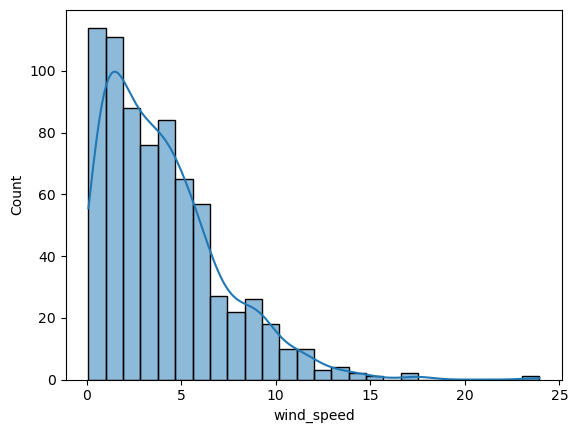

In [5]:
# A histogram is the natural choice for a quantitative distribution; kde=True overlays
# the smoothed density curve seen in the example.
sns.histplot(data=bigfoot, x='wind_speed', kde=True)
plt.show()

### Part C

Now, let's look at some qualitative variables. Write a line of code that produces a visualization that shows the distribution of bigfoot sightings across the variable `season` (example shown below). 

**Hint:** Use `seaborn`'s `sns.countplot` or `matplotlib`'s `plt.bar`.

![](images/season_bar.png)

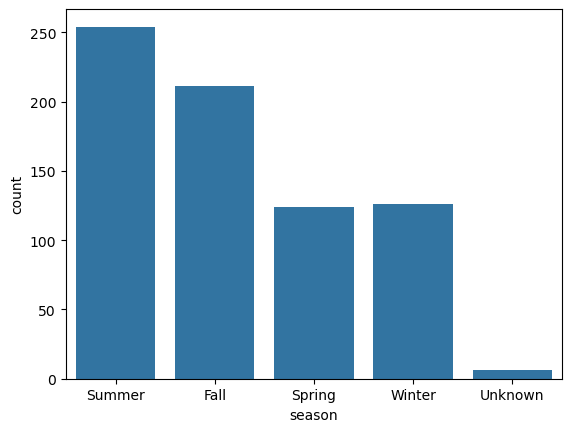

In [6]:
# `season` is qualitative, so we count sightings per category rather than binning.
# countplot leaves the bars in order of first appearance, matching the example.
sns.countplot(data=bigfoot, x='season')
plt.show()

### Part D

Finally, produce a single visualization that showcases how the prevalence of bigfoot sightings at particular combinations of `moon_phase` and `wind_speed` vary across each season.

**Hint**: Think about color as the third information channel in the plot.

![](images/moon_vs_wind.png)

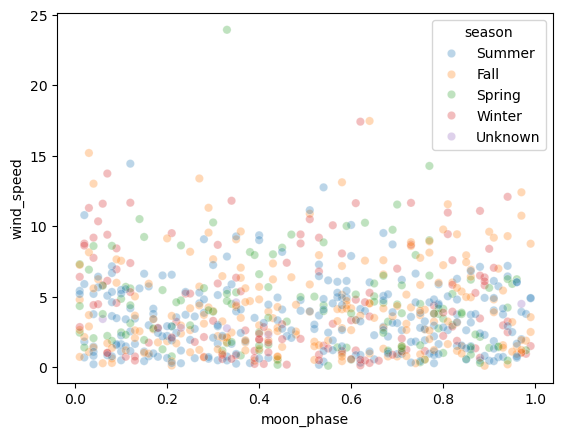

In [7]:
# moon_phase and wind_speed are both quantitative, so they go on the two axes as a
# scatter plot. `season` is the third variable, and being qualitative it is best
# encoded as color via `hue`. alpha makes the heavy overplotting near the bottom of
# the plot readable.
sns.scatterplot(data=bigfoot, x='moon_phase', y='wind_speed', hue='season', alpha=0.3)
plt.show()